# Proyecto Final

## Integrantes

- Sergio Orellana - 221122
- Andy Fuentes - 22944
- Christian Echeverria - 221441
- Jorge Lopez - 221038
- Davis Roldan - 22672

### Link del Repositorio

https://github.com/Ctribsz/ProyectoFinal-DM


## Análisis exploratorio

En este notebook realizaremos:

1. **Evaluación de la calidad de datos**: Revisión de dimensiones, tipos de datos, valores nulos y duplicados de cada CSV.
2. **Resúmenes estadísticos**: Análisis descriptivo (medias, desviaciones, percentiles, etc.) de las variables numéricas.
3. **Visualización de patrones clave**: Gráficos para identificar distribuciones y relaciones relevantes.
4. **Análisis de correlación de características**: Exploración de relaciones entre variables numéricas en datasets individuales y combinados.

Asegúrate de tener instaladas las librerías necesarias: `pandas`, `numpy`, `matplotlib` y `seaborn`.


### Importar librerías


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io

### Carga de los datasets


In [ ]:
df_customers = pd.read_csv("./content/olist_customers_dataset.csv")
df_geolocation = pd.read_csv("./content/olist_geolocation_dataset.csv")
df_order_items = pd.read_csv("./content/olist_order_items_dataset.csv")
df_order_payments = pd.read_csv("./content/olist_order_payments_dataset.csv")
df_order_reviews = pd.read_csv("./content/olist_order_reviews_dataset.csv")
df_orders = pd.read_csv("./content/olist_orders_dataset.csv")
df_products = pd.read_csv("./content/olist_products_dataset.csv")
df_sellers = pd.read_csv("./content/olist_sellers_dataset.csv")
df_prod_cat_trans = pd.read_csv("./content/product_category_name_translation.csv")

# df_customers = pd.read_csv("./Data/olist_customers_dataset.csv")
# df_geolocation = pd.read_csv("./Data/olist_geolocation_dataset.csv")
# df_order_items = pd.read_csv("./Data/olist_order_items_dataset.csv")
# df_order_payments = pd.read_csv("./Data/olist_order_payments_dataset.csv")
# df_order_reviews = pd.read_csv("./Data/olist_order_reviews_dataset.csv")
# df_orders = pd.read_csv("./Data/olist_orders_dataset.csv")
# df_products = pd.read_csv("./Data/olist_products_dataset.csv")
# df_sellers = pd.read_csv("./Data/olist_sellers_dataset.csv")
# df_prod_cat_trans = pd.read_csv("./Data/product_category_name_translation.csv")

### Evaluación de la calidad de datos

Revisamos las siguientes cuestiones:

- Dimensiones (número de filas y columnas)
- Información general y tipos de datos
- Valores nulos por columna
- Registros duplicados

A continuación, se realiza este chequeo para cada dataset.


In [ ]:
datasets = {
    "olist_customers_dataset": df_customers,
    "olist_geolocation_dataset": df_geolocation,
    "olist_order_items_dataset": df_order_items,
    "olist_order_payments_dataset": df_order_payments,
    "olist_order_reviews_dataset": df_order_reviews,
    "olist_orders_dataset": df_orders,
    "olist_products_dataset": df_products,
    "olist_sellers_dataset": df_sellers,
    "product_category_name_translation": df_prod_cat_trans,
}

for name, df in datasets.items():
    print(f"### {name}")
    print("Dimensiones:", df.shape)
    print("\nInformación:")
    print(df.info())
    print("\nValores nulos por columna:")
    print(df.isnull().sum())
    print("Registros duplicados:", df.duplicated().sum())

    print("\n" + "=" * 70 + "\n")

### olist_customers_dataset
Dimensiones: (99441, 5)

Información:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None

Valores nulos por columna:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
Registros duplicados: 0


### olist_geolocation_dataset
Dimensiones: (1000163, 5)

Información:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 colu

#### **Analisis descriptivo**

1. **olist_customers_dataset**

- Dimensiones y Estructura:
  Contiene 99,441 registros y 5 columnas.

- Contenido y Calidad:
  Todas las filas están completas (sin valores nulos) para las columnas de identificación, código postal, ciudad y estado.

- Observaciones:
  El dataset es muy consistente, ya que no presenta duplicados ni datos faltantes. Esto indica que la información de los clientes (incluyendo el identificador único y la ubicación) es confiable y se puede utilizar directamente para realizar análisis demográficos o para vincular con otros datasets (por ejemplo, al hacer joins con pedidos).

2. **olist_geolocation_dataset**

- Dimensiones y Estructura:
  Contiene 1,000,163 registros repartidos en 5 columnas (prefijo de código postal, latitud, longitud, ciudad y estado).

- Contenido y Calidad:
  No presenta valores nulos; sin embargo, se detectaron 261,831 registros duplicados.

- Observaciones:
  La alta cantidad de duplicados sugiere que existen múltiples entradas para algunos códigos postales. Esto puede ser deliberado (por ejemplo, diversas coordenadas o ubicaciones que corresponden al mismo código postal) o podría requerir una depuración, especialmente si el objetivo es generar una lista única de ubicaciones o realizar análisis geoespaciales precisos.

3. **olist_order_items_dataset**

- Dimensiones y Estructura:
  Consta de 112,650 registros y 7 columnas, que incluyen identificadores de órdenes y productos, detalles del vendedor, fecha límite de envío, precio y valor del frete.

- Contenido y Calidad:
  No hay datos nulos ni duplicados en este conjunto; los campos numéricos (como precio y valor del frete) tienen el tipo de dato adecuado (float64).

- Observaciones:
  Este dataset está limpio y preparado para realizar análisis de costos, distribución de precios y frete, y detectar posibles outliers en las transacciones.

4. **olist_order_payments_dataset**

- Dimensiones y Estructura:
  Consta de 103,886 registros y 5 columnas, incluyendo el identificador de la orden, secuencia de pago, tipo de pago, número de cuotas y valor de pago.

- Contenido y Calidad:
  No se detectan valores nulos ni duplicados.

- Observaciones:
  La calidad de estos datos es alta y permite realizar análisis sobre métodos de pago, distribución de cuotas y correlación entre forma de pago y valor de transacción. Es importante notar la diferencia en el número de registros respecto a otros datasets, lo que puede indicar que algunas órdenes pueden tener más de un registro en el contexto de pagos.

5. **olist_order_reviews_dataset**

- Dimensiones y Estructura:
  Incluye 99,224 registros y 7 columnas relacionadas con evaluaciones de las órdenes.

- Contenido y Calidad:

Los campos críticos como review_id, order_id, review_score, review_creation_date y review_answer_timestamp están completos.

Las columnas de comentarios (review_comment_title y review_comment_message) tienen un alto porcentaje de valores nulos (por ejemplo, solo alrededor de 11,568 registros tienen título y 40,977 contienen mensaje), lo que puede reflejar que no todos los clientes dejan retroalimentación textual.

- Observaciones:
  Aunque la puntuación numérica (score) es íntegra, la información cualitativa (comentarios) es esporádica, lo que sugiere que para análisis de sentimiento o de texto se trabajará únicamente con la información disponible o se aplicarán técnicas para tratar la ausencia de estos datos.

6. **olist_orders_dataset**

- Dimensiones y Estructura:
  Contiene 99,441 registros y 8 columnas relacionadas con el ciclo completo de una orden (compra, aprobación y fechas de entrega).

- Contenido y Calidad:

La mayoría de las columnas están completas; sin embargo, existen algunos valores nulos en columnas de fechas:

order_approved_at: 160 nulos.

order_delivered_carrier_date: 1,783 nulos.

order_delivered_customer_date: 2,965 nulos.

Esto es común en escenarios donde algunas órdenes pueden no haberse completado o existir retrasos en la actualización.

- Observaciones:
  El dataset es esencial para analizar el ciclo de vida de los pedidos, y los campos con valores nulos se deben revisar para entender qué significan en el contexto del negocio (por ejemplo, pedidos cancelados o retrasados). Las fechas se deben convertir a formato datetime para facilitar el análisis temporal.

7. **olist_products_dataset**

- Dimensiones y Estructura:
  Consta de 32,951 registros y 9 columnas, incluyendo identificadores de producto, detalles físicos y de la descripción.

- Contenido y Calidad:

La mayoría de las columnas tienen datos casi completos, salvo en columnas relacionadas con detalles descriptivos (como product_category_name, product_name_lenght, product_description_lenght y product_photos_qty), donde se observan aproximadamente 610 registros nulos (alrededor del 1.8-2% de los registros).

Los atributos físicos (peso, dimensiones) tienen muy pocos valores nulos, lo que sugiere que la mayoría de los productos cuentan con información detallada de sus características.

- Observaciones:
  Este dataset es crucial para clasificar productos y relacionar características físicas con el tipo de producto. La poca cantidad de datos faltantes en campos clave permite un análisis robusto y confiable.

8. **olist_sellers_dataset**

- Dimensiones y Estructura:
  Contiene 3,095 registros y 4 columnas que incluyen el identificador del vendedor, el código postal, la ciudad y el estado.

- Contenido y Calidad:
  No se reportan valores nulos ni duplicados.

- Observaciones:
  La información de los vendedores es completa y puede utilizarse para evaluar el impacto de la localización o la reputación de un vendedor en la logística y tiempos de entrega. Es ideal para vincular con otros datos (por ejemplo, dentro del análisis de pedidos o envío).

9. **product_category_name_translation**

- Dimensiones y Estructura:
  Este dataset es relativamente pequeño con 71 registros y 2 columnas (nombre de la categoría en portugués y su traducción al inglés).

- Contenido y Calidad:
  Todas las entradas están completas sin valores nulos ni duplicados.

- Observaciones:
  Este archivo es fundamental para la interpretación de categorías de producto en contextos internacionales o para reportes en inglés, permitiendo una estandarización de la nomenclatura en análisis posteriores.


### Resúmenes Estadísticos

En esta sección haremos resúmenes estadísticos para cada dataset utilizando el método `.describe()`.

Se muestran:

- **Resumen numérico:** Estadísticas básicas (conteo, media, desviación estándar, mínimo, percentiles y máximo) para columnas numéricas.
- **Resumen categórico:** Estadísticas descriptivas (conteo, número de valores únicos, valor más frecuente y su frecuencia) para columnas de tipo objeto.

Esto nos ayudará a identificar la dispersión de las variables, detectar posibles outliers y entender la distribución de las categorías.


In [ ]:
def show_summary_stats(df, dataset_name):
    print(f"### {dataset_name}")

    # Resumen numérico: para variables numéricas
    print("\n#### Resumen numérico:")
    print(df.describe())

    # Resumen categórico: para variables de tipo object (cadenas de texto)
    print("\n#### Resumen categórico:")
    print(df.describe(include=["object"]))

    print("\n" + "=" * 70 + "\n")


# Diccionario de datasets (asegúrate de haber cargado previamente los CSV)
datasets = {
    "olist_customers_dataset": df_customers,
    "olist_geolocation_dataset": df_geolocation,
    "olist_order_items_dataset": df_order_items,
    "olist_order_payments_dataset": df_order_payments,
    "olist_order_reviews_dataset": df_order_reviews,
    "olist_orders_dataset": df_orders,
    "olist_products_dataset": df_products,
    "olist_sellers_dataset": df_sellers,
    "product_category_name_translation": df_prod_cat_trans,
}

# Iteramos sobre cada dataset y mostramos los resúmenes
for name, df in datasets.items():
    show_summary_stats(df, name)

### olist_customers_dataset

#### Resumen numérico:
       customer_zip_code_prefix
count              99441.000000
mean               35137.474583
std                29797.938996
min                 1003.000000
25%                11347.000000
50%                24416.000000
75%                58900.000000
max                99990.000000

#### Resumen categórico:
                             customer_id                customer_unique_id  \
count                              99441                             99441   
unique                             99441                             96096   
top     274fa6071e5e17fe303b9748641082c8  8d50f5eadf50201ccdcedfb9e2ac8455   
freq                                   1                                17   

       customer_city customer_state  
count          99441          99441  
unique          4119             27  
top        sao paulo             SP  
freq           15540          41746  


### olist_geolocation_dataset

#### Resumen numéric

# Análisis Descriptivo de los Datos

## olist_customers_dataset

### Resumen Numérico

- **customer_zip_code_prefix:**
  - **Count:** 99,441
  - **Media:** 35,137.47
  - **Desviación Estándar:** 29,797.94
  - **Mínimo:** 1,003
  - **Percentil 25:** 11,347
  - **Mediana (50%):** 24,416
  - **Percentil 75:** 58,900
  - **Máximo:** 99,990

_Interpretación:_  
Aunque los códigos postales son tratados numéricamente, en realidad son identificadores geográficos. El amplio rango y alta desviación indican una gran diversidad en la ubicación de los clientes.

### Resumen Categórico

- **customer_id:**
  - **Count:** 99,441
  - **Unique:** 99,441
  - **Top:** "06b8999e2fba1a1fbc88172c00ba8bc7" (frecuencia 1)
- **customer_unique_id:**
  - **Count:** 99,441
  - **Unique:** 96,096
  - **Top:** "8d50f5eadf50201ccdcedfb9e2ac8455" (frecuencia 17)
- **customer_city:**
  - **Count:** 99,441
  - **Unique:** 4,119
  - **Top:** "sao paulo" (15,540 apariciones)
- **customer_state:**
  - **Count:** 99,441
  - **Unique:** 27
  - **Top:** "SP" (41,746 apariciones)

## olist_geolocation_dataset

### Resumen Numérico

- **geolocation_zip_code_prefix:**
  - **Count:** ~1,000,163
  - **Media:** 36,574.17
  - **Desviación:** 30,549.34
  - **Mínimo:** 1,001
  - **Percentiles 25, 50 y 75:** 11,075; 26,530; 63,504
  - **Máximo:** 99,990
- **geolocation_lat y geolocation_lng:**
  - Los valores presentan rangos amplios (indicativos de una cobertura geográfica extensa).

_Interpretación:_  
Aunque la base abarca una gran área, se detectaron **261,831 duplicados**, lo cual sugiere que existen múltiples registros para el mismo código postal.

### Resumen Categórico

- **geolocation_city:**
  - **Count:** 1,000,163
  - **Unique:** 8,011
  - **Top:** "sao paulo" (135,800 apariciones)
- **geolocation_state:**
  - **Count:** 1,000,163
  - **Unique:** 27
  - **Top:** "SP" (404,268 apariciones)

## olist_order_items_dataset

### Resumen Numérico

- **order_item_id:**
  - **Count:** 112,650
  - **Mediana:** 1 (la mayoría de las órdenes tienen un solo item; sin embargo, el máximo es 21, indicando pedidos múltiples).
- **price:**
  - **Media:** 120.65
  - **Rango:** 0.85 a 6,735.00
  - **Desviación:** 183.63
- **freight_value:**
  - **Media:** 19.99
  - **Rango:** 0 a 409.68

_Interpretación:_  
Se observa una amplia variabilidad en los precios y en el valor del frete, lo que permite identificar potenciales outliers y la diversidad en el valor de las transacciones.

### Resumen Categórico

- **order_id:**
  - **Count:** 112,650
  - **Unique:** 98,666
- **product_id:**
  - **Unique:** 32,951
- **seller_id:**
  - **Unique:** 3,095
- **shipping_limit_date:**
  - Top: "2017-07-21 18:25:23" (frecuencia 21)

## olist_order_payments_dataset

### Resumen Numérico

- **payment_sequential:**
  - **Media:** 1.09, lo que indica que la mayoría de las órdenes tiene un único registro de pago (aunque se observan hasta 29).
- **payment_installments:**
  - **Media:** 2.85 (el máximo es 24, mostrando pagos divididos en cuotas).
- **payment_value:**
  - **Media:** 154.10
  - **Rango:** 0 a 13,664.08

_Interpretación:_  
Existe una amplia variabilidad en los valores de transacción y en la forma de pago, lo que es clave para comprender las estrategias de financiamiento y segmentar a los clientes según sus preferencias.

### Resumen Categórico

- **order_id:**
  - **Unique:** 99,440
- **payment_type:**
  - **Top:** "credit_card" (76,795 ocurrencias)

## olist_order_reviews_dataset

### Resumen Numérico

- **review_score:**
  - **Media:** 4.09
  - **Rango:** 1 a 5, con la mediana y percentiles concentrados en 4 y 5.

_Interpretación:_  
La mayoría de los reviews son positivos, lo cual es una señal de satisfacción general. Sin embargo, la existencia de valores bajos (mínimo 1) permite analizar en detalle los factores que generan insatisfacción.

### Resumen Categórico

- **review_id y order_id:**
  - Alta diversidad en identificadores.
- **review_comment_title y review_comment_message:**
  - Muchos registros presentan valores nulos; solo una fracción de clientes deja comentarios textuales.
  - Títulos y mensajes frecuentes como "Recomendo" y "Muito bom" indican, en general, feedback positivo.
- **review_creation_date:**
  - Variedad en las fechas sugiere un historial temporal consistente para el análisis.

## olist_orders_dataset

### Resumen Numérico & Categórico

- **order_status:**
  - Predomina el estado **"delivered"** (96,478 ocurrencias), lo que indica alta tasa de cumplimiento.
- **Fechas (order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date):**
  - Amplia diversidad y presencia de nulos en algunas columnas (por ejemplo, 160 nulos en `order_approved_at`, 1,783 en `order_delivered_carrier_date` y 2,965 en `order_delivered_customer_date`).

_Interpretación:_  
El dataset es fundamental para analizar el ciclo de vida de un pedido. Los diferentes timestamps permiten calcular tiempos de entrega y retrasos. Los valores nulos pueden representar pedidos no completados o retrasos en el registro, por lo que hay que hacer un manejo especial en el preprocesamiento.

## olist_products_dataset

### Resumen Numérico

- **Medidas de Texto:**
  - `product_name_lenght` tiene una media de 48.48 caracteres.
  - `product_description_lenght` tiene una media de 771.50 caracteres.
  - `product_photos_qty` muestra una media de 2.19 fotos, con valores que varían hasta 20.
- **Medidas Físicas:**
  - `product_weight_g`: media de 2,276.47 g (muy variable, de 0 a 40,425 g).
  - `product_length_cm`, `product_height_cm` y `product_width_cm`: presentan variabilidad que es crítica para análisis logísticos y de costos.

_Interpretación:_  
La descripción y características físicas de los productos permiten segmentar el catálogo, identificar categorías con mayor detalle y relacionarlas con el comportamiento de compra o los costos de envío.

### Resumen Categórico

- **product_id:**
  - Cada producto es único (32,951 en total).
- **product_category_name:**
  - Hay 73 categorías, destacando “cama_mesa_banho” (3,029 apariciones) como la más frecuente.

La diversidad de productos es alta, lo que obliga a segmentar el análisis para identificar patrones por categoría y mejorar estrategias de marketing, inventario y logística.

## olist_sellers_dataset

### Resumen Numérico

- **seller_zip_code_prefix:**
  - **Media:** 32,291.06
  - Rango amplio (de 1,001 a 99,730)

_Interpretación:_  
Existe gran diversidad geográfica en la ubicación de los vendedores, lo que puede impactar en la logística y en tiempos de envío.

### Resumen Categórico

- **seller_id:**
  - Cada vendedor es único (3,095 registros).
- **seller_city y seller_state:**
  - Destacan “sao paulo” y “SP”, lo que sugiere una alta concentración de vendedores en esa región.

La base de vendedores es completa y permite analizar el impacto de la localización en el desempeño logístico y la satisfacción del cliente.

## product_category_name_translation

### Resumen Numérico y Categórico

- **Características:**
  - El dataset es pequeño (71 registros), pero cada registro es único.
  - Se utiliza para traducir y estandarizar los nombres de categorías de producto (por ejemplo, "beleza_saude" se traduce a "health_beauty").

Aunque es un dataset reducido, es fundamental para interpretar correctamente las categorías de productos, especialmente en análisis internacionales o reportes en inglés.


## Análisis de Valores Faltantes

Revisa de forma visual dónde están concentrados los valores nulos. Esto te ayuda a decidir si imputar o eliminar.


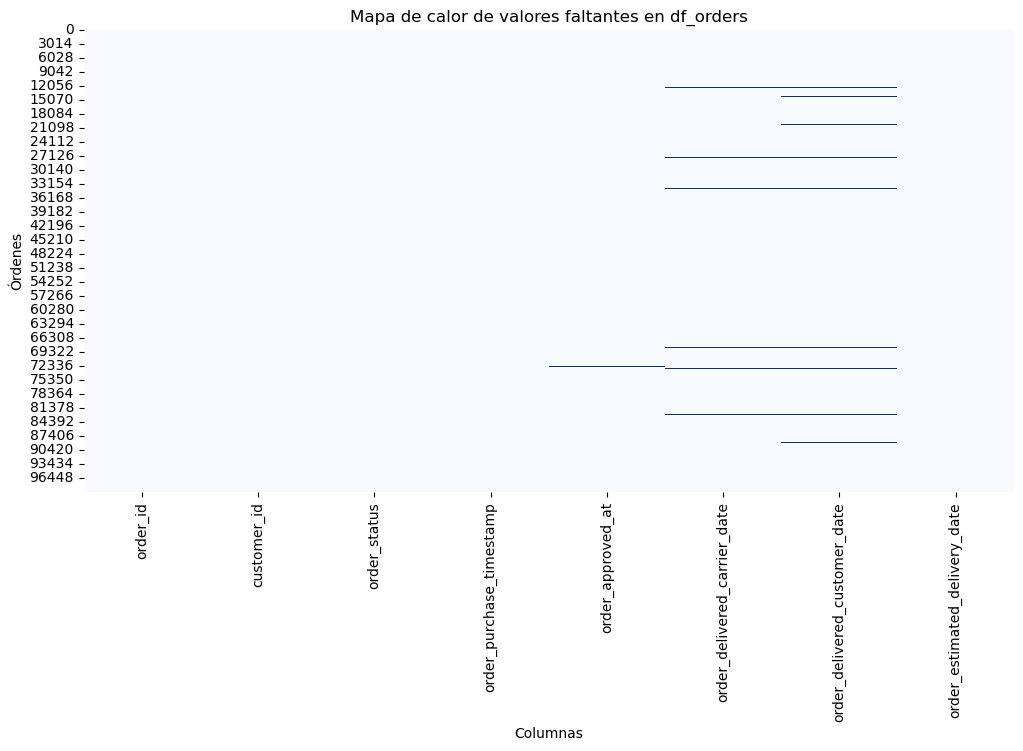

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.heatmap(df_orders.isnull(), cbar=False, cmap="Blues")
plt.title("Mapa de calor de valores faltantes en df_orders")
plt.xlabel("Columnas")
plt.ylabel("Órdenes")
plt.show()

**Explicación:**

El mapa de calor muestra que la mayoría de las columnas en df_orders están completas, salvo en order_approved_at, order_delivered_carrier_date y order_delivered_customer_date, donde se identifican varios valores nulos. Esto podría indicar órdenes que fueron canceladas, no completadas o que aún estaban en proceso al momento de la captura de datos. Es importante considerar estos nulos en el preprocesamiento para evitar errores en modelos predictivos o cálculos de tiempos de entrega.


## Distribución Geográfica de Órdenes

Cuenta cuántas órdenes hay por estado de cliente y muéstralo en un barplot.


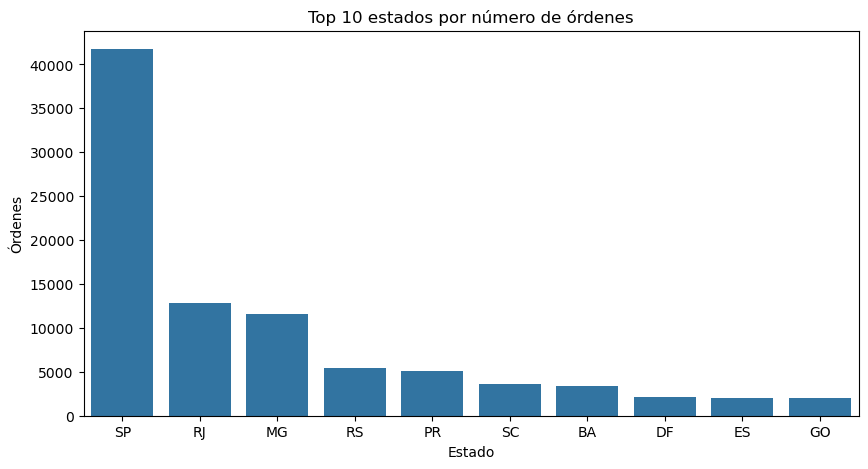

In [ ]:
orders_by_state = df_orders["customer_id"].map(
    df_customers.set_index("customer_id")["customer_state"]
)
orders_by_state = orders_by_state.value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=orders_by_state.index, y=orders_by_state.values)
plt.title("Top 10 estados por número de órdenes")
plt.xlabel("Estado")
plt.ylabel("Órdenes")
plt.show()

**Explicación:**

La gráfica evidencia que el estado de São Paulo (SP) concentra la mayor cantidad de órdenes realizadas, seguido por Río de Janeiro (RJ) y Minas Gerais (MG). Esta concentración sugiere que la operación logística y comercial de Olist tiene un foco fuerte en regiones altamente urbanizadas y pobladas de Brasil, donde podría tener sentido reforzar estrategias de logística o atención al cliente.


## Métodos de Pago

Visualiza la proporción de cada tipo de pago.


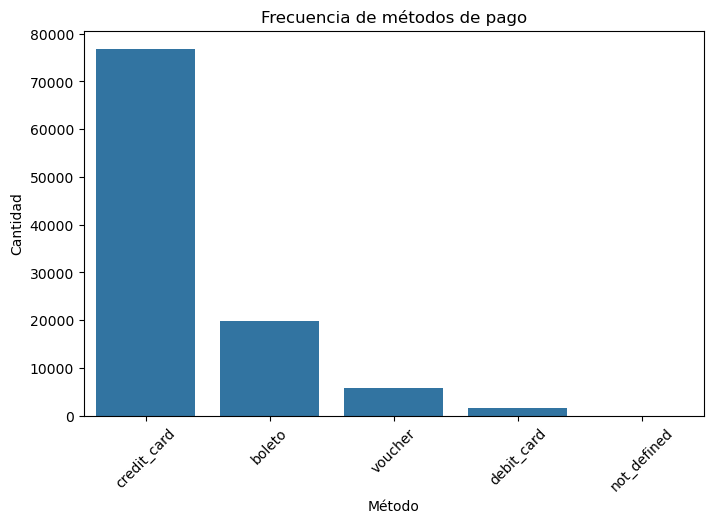

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_order_payments, x="payment_type")
plt.title("Frecuencia de métodos de pago")
plt.xlabel("Método")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.show()

**Explicación:**

El método de pago más utilizado es la tarjeta de crédito (credit_card), representando una gran mayoría de las transacciones. Métodos como boleto (boleto bancario) y voucher tienen una participación menor. Esto muestra que los clientes prefieren medios de pago rápidos y prácticos, lo que puede orientar campañas promocionales o decisiones relacionadas a opciones de financiamiento.


## Análisis de Categorías de Producto

Cuenta y grafica las 10 categorías más vendidas (usando la traducción al inglés).


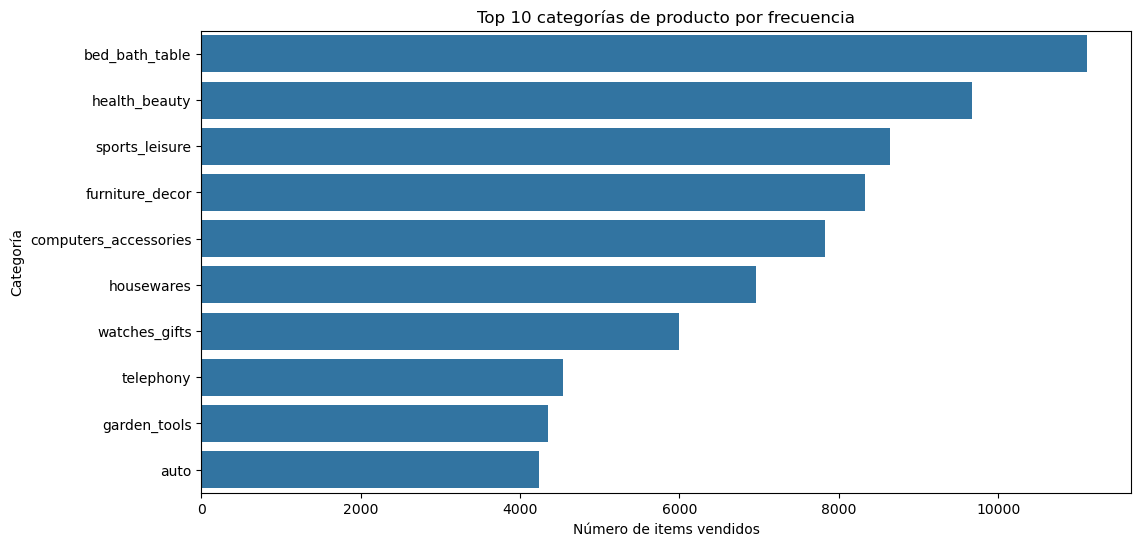

In [ ]:
df_prod = df_products.merge(df_prod_cat_trans, on="product_category_name", how="left")
# Contar ventas por categoría
top_cats = (
    df_order_items.merge(
        df_prod[["product_id", "product_category_name_english"]], on="product_id"
    )
    .groupby("product_category_name_english")
    .size()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_cats.values, y=top_cats.index)
plt.title("Top 10 categorías de producto por frecuencia")
plt.xlabel("Número de items vendidos")
plt.ylabel("Categoría")
plt.show()

**Explicación:**

Las categorías bed_bath_table, health_beauty y sports_leisure son las más vendidas dentro del marketplace de Olist. Esto indica que los artículos para el hogar, el cuidado personal y el entretenimiento deportivo son segmentos clave para la empresa. Entender qué categorías dominan permite enfocar esfuerzos de marketing, inventario y experiencia del cliente hacia estos sectores de alta demanda.


## Precio promedio vs días de retraso en entrega

Explora cómo varía el precio medio de la orden según el retraso en la entrega.


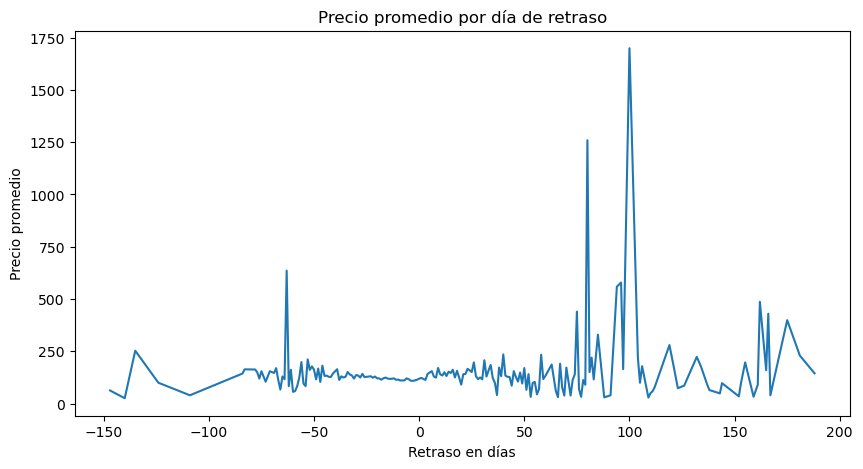

In [ ]:
df_order_items_orders = df_order_items.merge(
    df_orders[
        ["order_id", "order_delivered_customer_date", "order_estimated_delivery_date"]
    ],
    on="order_id",
    how="left",
)

# Convertir fechas
df_order_items_orders["order_delivered_customer_date"] = pd.to_datetime(
    df_order_items_orders["order_delivered_customer_date"]
)
df_order_items_orders["order_estimated_delivery_date"] = pd.to_datetime(
    df_order_items_orders["order_estimated_delivery_date"]
)

# Crear columna de retraso
df_order_items_orders["delivery_delay"] = (
    df_order_items_orders["order_delivered_customer_date"]
    - df_order_items_orders["order_estimated_delivery_date"]
).dt.days

# Agrupar
delay_price = (
    df_order_items_orders.groupby("delivery_delay")["price"].mean().reset_index()
)

# Graficar
plt.figure(figsize=(10, 5))
sns.lineplot(data=delay_price, x="delivery_delay", y="price")
plt.title("Precio promedio por día de retraso")
plt.xlabel("Retraso en días")
plt.ylabel("Precio promedio")
plt.show()

**Explicación:**

La gráfica muestra una alta dispersión en el precio promedio de los productos conforme aumentan los días de retraso. Sin embargo, en general, los precios se mantienen estables en torno a valores bajos, salvo algunos picos importantes a partir de 50 días de retraso. Estos picos podrían deberse a productos de muy alto valor que tienden a retrasarse más, como muebles o electrónicos grandes, sugiriendo que productos caros podrían necesitar estrategias logísticas diferenciadas.


## Retraso en la entrega según review score


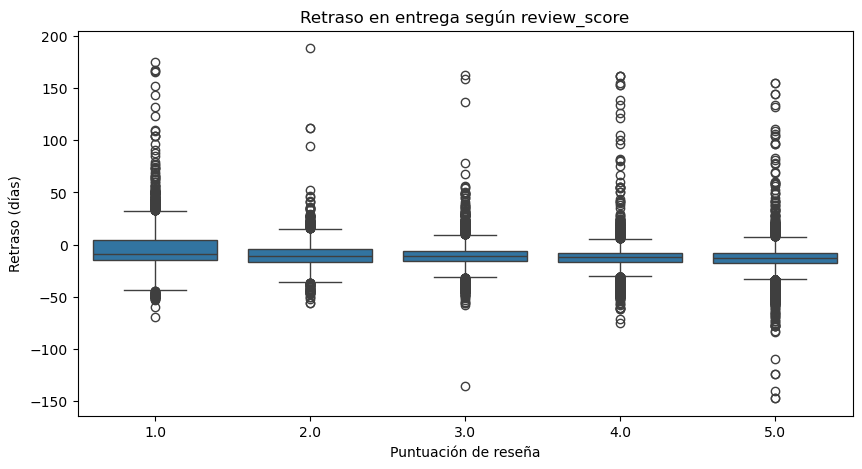

In [ ]:
# Unir órdenes, ítems y reviews
df_complete = df_orders.merge(
    df_order_items[["order_id", "price"]], on="order_id", how="left"
)
df_complete = df_complete.merge(
    df_order_reviews[["order_id", "review_score"]], on="order_id", how="left"
)

# Fechas
df_complete["order_delivered_customer_date"] = pd.to_datetime(
    df_complete["order_delivered_customer_date"]
)
df_complete["order_estimated_delivery_date"] = pd.to_datetime(
    df_complete["order_estimated_delivery_date"]
)

# Retraso
df_complete["delivery_delay"] = (
    df_complete["order_delivered_customer_date"]
    - df_complete["order_estimated_delivery_date"]
).dt.days

# Graficar
plt.figure(figsize=(10, 5))
sns.boxplot(x="review_score", y="delivery_delay", data=df_complete)
plt.title("Retraso en entrega según review_score")
plt.xlabel("Puntuación de reseña")
plt.ylabel("Retraso (días)")
plt.show()

**Explicación:**

El boxplot muestra que las órdenes que recibieron puntuaciones más bajas (1 o 2) tienden a presentar mayores retrasos en la entrega, mientras que las puntuaciones más altas (4 y 5) están asociadas a entregas realizadas dentro del plazo o con menores retrasos. Esto confirma que el tiempo de entrega es un factor crítico que influye directamente en la satisfacción del cliente, y sugiere que reducir los retrasos puede mejorar la percepción de servicio.


# **Análisis de correlación de características**


In [ ]:
import pandas as pd

# Convertimos fechas
df_orders["order_purchase_timestamp"] = pd.to_datetime(
    df_orders["order_purchase_timestamp"]
)
df_orders["order_delivered_customer_date"] = pd.to_datetime(
    df_orders["order_delivered_customer_date"]
)

# Creamos columna: delivery_days
df_orders["delivery_days"] = (
    df_orders["order_delivered_customer_date"] - df_orders["order_purchase_timestamp"]
).dt.days

# Merge secuencial por 'order_id'
df = df_orders[["order_id", "delivery_days"]].dropna()
df = df.merge(
    df_order_items[["order_id", "price", "freight_value"]], on="order_id", how="inner"
)
df = df.merge(
    df_order_payments[["order_id", "payment_value", "payment_installments"]],
    on="order_id",
    how="inner",
)
df = df.merge(
    df_order_reviews[["order_id", "review_score"]], on="order_id", how="inner"
)

# Merge con products (usando product_id, hay que pasar por order_items)
df = df.merge(df_order_items[["order_id", "product_id"]], on="order_id", how="inner")
df = df.merge(
    df_products[["product_id", "product_photos_qty", "product_weight_g"]],
    on="product_id",
    how="inner",
)

# Eliminar duplicados por si acaso
df = df.drop_duplicates()

# Visualizar las primeras filas
df.head()

,order_id,delivery_days,price,freight_value,payment_value,payment_installments,review_score,product_id,product_photos_qty,product_weight_g
0,e481f51cbdc54678b7cc49136f2d6af7,8.0,29.99,8.72,18.12,1,4,87285b34884572647811a353c7ac498a,4.0,500.0
1,e481f51cbdc54678b7cc49136f2d6af7,8.0,29.99,8.72,2.00,1,4,87285b34884572647811a353c7ac498a,4.0,500.0
2,e481f51cbdc54678b7cc49136f2d6af7,8.0,29.99,8.72,18.59,1,4,87285b34884572647811a353c7ac498a,4.0,500.0
3,53cdb2fc8bc7dce0b6741e2150273451,13.0,118.70,22.76,141.46,1,4,595fac2a385ac33a80bd5114aec74eb8,1.0,400.0
4,47770eb9100c2d0c44946d9cf07ec65d,9.0,159.90,19.22,179.12,3,5,aa4383b373c6aca5d8797843e5594415,1.0,420.0


En este bloque se construyó un nuevo DataFrame a partir de múltiples fuentes del dataset de Olist, utilizando order_id como clave principal de unión. Se integraron las siguientes fuentes:

df_orders: Se utilizó para calcular delivery_days, es decir, la cantidad de días entre la compra y la entrega real.

df_order_items: Aportó los campos price y freight_value por cada producto en una orden.

df_order_payments: Se extrajeron los campos payment_value y payment_installments.

df_order_reviews: Proporcionó la variable objetivo de satisfacción review_score.

df_products: Se unió a través de product_id, añadiendo características del producto como product_photos_qty y product_weight_g.

Finalmente, se eliminaron duplicados para evitar sesgos y se generó un dataframe unificado con las variables relevantes para el análisis. Este conjunto de datos sirve como base para el modelado y análisis exploratorio posterior.


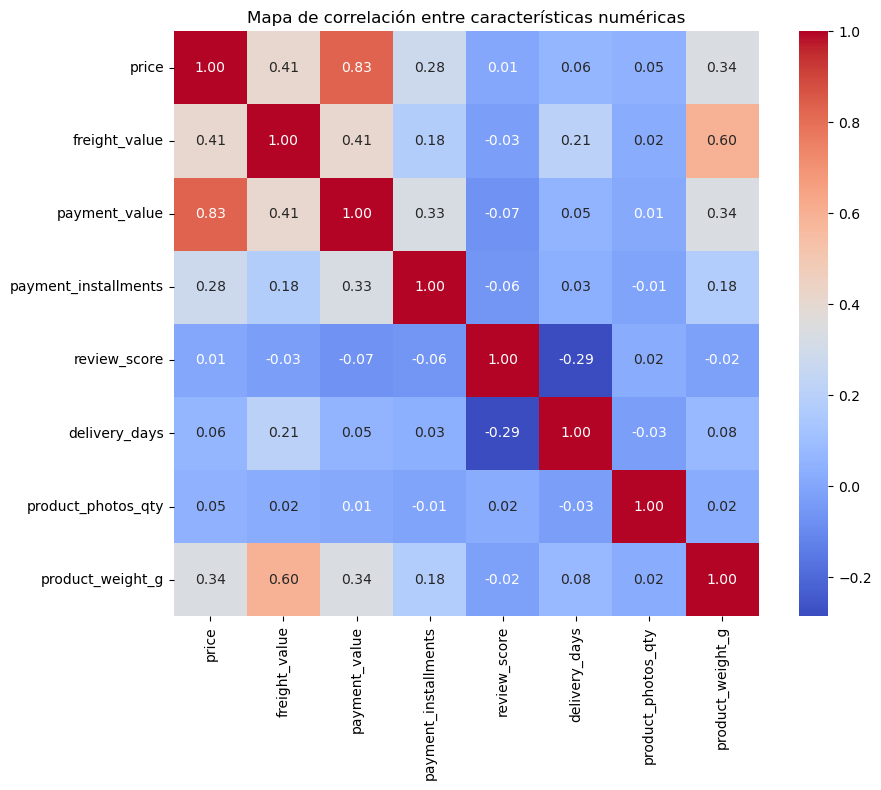

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Variables numéricas para analizar
correlation_vars = [
    "price",
    "freight_value",
    "payment_value",
    "payment_installments",
    "review_score",
    "delivery_days",
    "product_photos_qty",
    "product_weight_g",
]

# Filtrar y eliminar nulos
df_corr = df[correlation_vars].dropna()

# Mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(), annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Mapa de correlación entre características numéricas")
plt.tight_layout()
plt.show()

El objetivo de este bloque fue identificar relaciones lineales entre las variables numéricas del dataset utilizando la matriz de correlación de Pearson y visualizarlas mediante un heatmap.

Los resultados más relevantes incluyen:

Alta correlación entre price y payment_value (0.83): refleja que el valor total pagado está estrechamente vinculado al precio del producto.

Correlación entre freight_value y product_weight_g (0.60): como era de esperarse, los productos más pesados tienden a generar mayores costos de envío.

Correlación negativa entre delivery_days y review_score (-0.29): un mayor tiempo de entrega se asocia a peores calificaciones por parte del cliente.

Relaciones débiles o nulas entre la mayoría de las otras variables, indicando que algunas podrían descartarse en el modelado si no aportan valor predictivo.

Este análisis ayuda a reducir la redundancia (por ejemplo, entre price y payment_value) y a enfocar los esfuerzos del modelado en variables más informativas.


## Dataset Preprocesado Listo para Modelado


In [ ]:
# Calcular días de entrega
df_orders["order_purchase_timestamp"] = pd.to_datetime(
    df_orders["order_purchase_timestamp"]
)
df_orders["order_delivered_customer_date"] = pd.to_datetime(
    df_orders["order_delivered_customer_date"]
)
df_orders["delivery_days"] = (
    df_orders["order_delivered_customer_date"] - df_orders["order_purchase_timestamp"]
).dt.days

# Merge secuencial por 'order_id'
df = df_orders[["order_id", "customer_id", "delivery_days"]].dropna()
df = df.merge(
    df_order_items[["order_id", "product_id", "seller_id", "price", "freight_value"]],
    on="order_id",
)
df = df.merge(
    df_order_payments[
        ["order_id", "payment_value", "payment_installments", "payment_type"]
    ],
    on="order_id",
)
df = df.merge(df_order_reviews[["order_id", "review_score"]], on="order_id")
df = df.merge(
    df_products[
        [
            "product_id",
            "product_category_name",
            "product_photos_qty",
            "product_weight_g",
        ]
    ],
    on="product_id",
)

## Agregar ubicación de cliente y vendedor


In [ ]:
df = df.merge(
    df_customers[["customer_id", "customer_state"]], on="customer_id", how="left"
)


df = df.merge(df_sellers[["seller_id", "seller_state"]], on="seller_id", how="left")

## Limpiar columnas y valores


In [ ]:
# Eliminar columnas que ya no se usarán
df.drop(columns=["order_id", "customer_id", "product_id", "seller_id"], inplace=True)

# Quitar duplicados y valores nulos importantes
df = df.drop_duplicates()
df = df.dropna(subset=["review_score", "delivery_days", "price", "freight_value"])

## Codificar variables categóricas


In [ ]:
df_model = pd.get_dummies(
    df,
    columns=["payment_type", "product_category_name", "customer_state", "seller_state"],
    drop_first=True,
)

## Exportar dataset final


In [ ]:
df_model.to_csv("dataset_final_para_modelo.csv", index=False)
df_model.head()

,delivery_days,price,freight_value,payment_value,payment_installments,review_score,product_photos_qty,product_weight_g,payment_type_credit_card,payment_type_debit_card,...,seller_state_PE,seller_state_PI,seller_state_PR,seller_state_RJ,seller_state_RN,seller_state_RO,seller_state_RS,seller_state_SC,seller_state_SE,seller_state_SP
0,8.0,29.99,8.72,18.12,1,4,4.0,500.0,True,False,...,False,False,False,False,False,False,False,False,False,True
1,8.0,29.99,8.72,2.00,1,4,4.0,500.0,False,False,...,False,False,False,False,False,False,False,False,False,True
2,8.0,29.99,8.72,18.59,1,4,4.0,500.0,False,False,...,False,False,False,False,False,False,False,False,False,True
3,13.0,118.70,22.76,141.46,1,4,1.0,400.0,False,False,...,False,False,False,False,False,False,False,False,False,True
4,9.0,159.90,19.22,179.12,3,5,1.0,420.0,True,False,...,False,False,False,False,False,False,False,False,False,True


# Entrga 2 - modelos de regresión

In [ ]:
import warnings
warnings.filterwarnings("ignore")  # silencia todos los warnings
warnings.filterwarnings(
    "ignore",
    message=".*ResourceTracker.*",
    category=UserWarning
)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import randint, uniform

In [ ]:
class C:
    GREEN  = '\033[92m'
    YELLOW = '\033[93m'
    RED    = '\033[91m'
    RESET  = '\033[0m'

# 0) Carga del dataset (ajusta la ruta según tu estructura)
df = pd.read_csv('dataset_final_para_modelo.csv')

# 1) Agrupar estados en regiones
region_map = {
    'Sudeste':     ['SP','RJ','MG','ES'],
    'Sur':         ['PR','SC','RS'],
    'Norte':       ['PA','AM','RO','AC','RR','AP','TO'],
    'Nordeste':    ['BA','PE','CE','PB','RN','PI','MA','AL','SE'],
    'CentroOeste': ['MT','MS','GO','DF']
}

for side in ['seller', 'customer']:
    for region, states in region_map.items():
        cols = [f'{side}_state_{st}' for st in states if f'{side}_state_{st}' in df.columns]
        df[f'{side}_region_{region}'] = df[cols].any(axis=1).astype(int)

# 2) Eliminar dummies originales de estado
drop_cols = [c for c in df.columns if c.startswith('seller_state_') or c.startswith('customer_state_')]
df.drop(columns=drop_cols, inplace=True)

# 3) Definir features y target y convertir todo a float
feature_cols = df.columns.drop(['delivery_days', 'price'])
df[feature_cols] = df[feature_cols].astype(float)
X = df[feature_cols]
y = df['delivery_days']

In [ ]:
# 4) División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5) Preprocesador: imputación + escalado
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',   StandardScaler())
])

# 6) Selector de top 30 features
selector = SelectFromModel(
    RandomForestRegressor(n_estimators=50, random_state=0),
    max_features=30, threshold=-np.inf
)

In [ ]:
# 7) Pipeline base
base_pipe = Pipeline([
    ('prep',   preprocessor),
    ('select', selector),
    ('model',  LinearRegression())
])

# 8) Espacio de búsqueda de modelos e hiperparámetros
param_dist = [
    {'model': [LinearRegression()]},
    {'model': [SVR(kernel='rbf')],
     'model__C': uniform(0.1, 10),
     'model__epsilon': uniform(0.05, 0.5)},
    {'model': [RandomForestRegressor(random_state=42)],
     'model__n_estimators': randint(50, 200),
     'model__max_depth': randint(5, 30)}
]

# 9) RandomizedSearchCV
search = RandomizedSearchCV(
    base_pipe,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=1,
    verbose=1,
    random_state=42
)
search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('prep',
                                              Pipeline(steps=[('imputer',
                                                               SimpleImputer(strategy='median')),
                                                              ('scaler',
                                                               StandardScaler())])),
                                             ('select',
                                              SelectFromModel(estimator=RandomForestRegressor(n_estimators=50,
                                                                                              random_state=0),
                                                              max_features=30,
                                                              threshold=-inf)),
                                             ('model', LinearRegression())]),
                   n_iter=20, n_jobs=1,
                   param_distributions=[{'mode...
                                         'model__epsilon': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x71f648285250>},
                                        {'model': [RandomForestRegressor(random_state=42)],
                                         'model__max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x71f64837e450>,
                                         'model__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x71f648214750>}],
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=1)

In [ ]:
# 10) Resultados RF
print(C.GREEN + "\n=== RESULTADOS RANDOM FOREST ===" + C.RESET)
print(C.YELLOW + f"Mejor RF: {search.best_params_}" + C.RESET)
rf_pred = search.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
r2_rf   = r2_score(y_test, rf_pred)
print(C.GREEN + f"RF → RMSE: {rmse_rf:.3f}, R2: {r2_rf:.3f}" + C.RESET)

# 11) Resultados LinearRegression
lr_pipe = Pipeline([('prep', preprocessor), ('select', selector), ('model', LinearRegression())])
lr_pipe.fit(X_train, y_train)
lr_pred = lr_pipe.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, lr_pred))
r2_lr   = r2_score(y_test, lr_pred)
print(C.GREEN + "\n=== RESULTADOS LINEAR REGRESSION ===" + C.RESET)
print(C.YELLOW + f"LinReg → RMSE: {rmse_lr:.3f}, R2: {r2_lr:.3f}" + C.RESET)

# 12) Resultados SVR
svr_pipe = Pipeline([('prep', preprocessor), ('select', selector),
                     ('model', SVR(kernel='rbf', C=1.0, epsilon=0.1))])
svr_pipe.fit(X_train, y_train)
svr_pred = svr_pipe.predict(X_test)
rmse_svr = np.sqrt(mean_squared_error(y_test, svr_pred))
r2_svr   = r2_score(y_test, svr_pred)
print(C.GREEN + "\n=== RESULTADOS SVR ===" + C.RESET)
print(C.YELLOW + f"SVR → RMSE: {rmse_svr:.3f}, R2: {r2_svr:.3f}" + C.RESET)


=== RESULTADOS RANDOM FOREST ===
Mejor RF: {'model': RandomForestRegressor(random_state=42), 'model__max_depth': 9, 'model__n_estimators': 100}
RF → RMSE: 8.069, R2: 0.279

=== RESULTADOS LINEAR REGRESSION ===
LinReg → RMSE: 8.439, R2: 0.211

=== RESULTADOS SVR ===
SVR → RMSE: 8.449, R2: 0.210


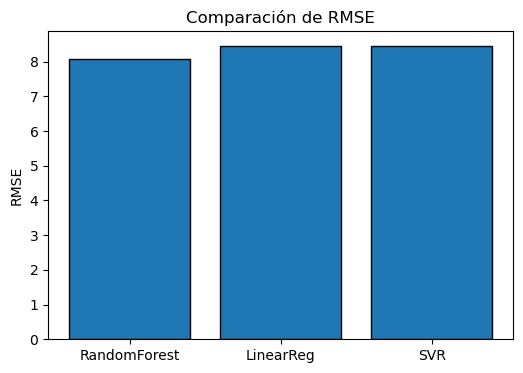

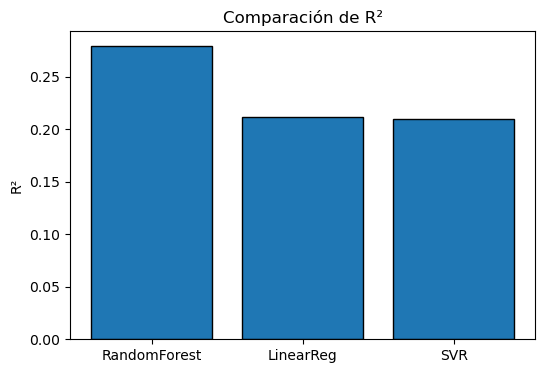


=== TOP 15 FEATURES (RF) ===
                                    Feature  Importance
0                             freight_value    0.351921
3                              review_score    0.269060
1                             payment_value    0.071279
5                          product_weight_g    0.059690
25                  customer_region_Sudeste    0.059012
28                 customer_region_Nordeste    0.039729
26                      customer_region_Sur    0.020768
27                    customer_region_Norte    0.018439
2                      payment_installments    0.015747
19  product_category_name_moveis_escritorio    0.014804
4                        product_photos_qty    0.013586
29              customer_region_CentroOeste    0.013139
6                  payment_type_credit_card    0.006202
24                        seller_region_Sur    0.006065
7                      payment_type_voucher    0.004650


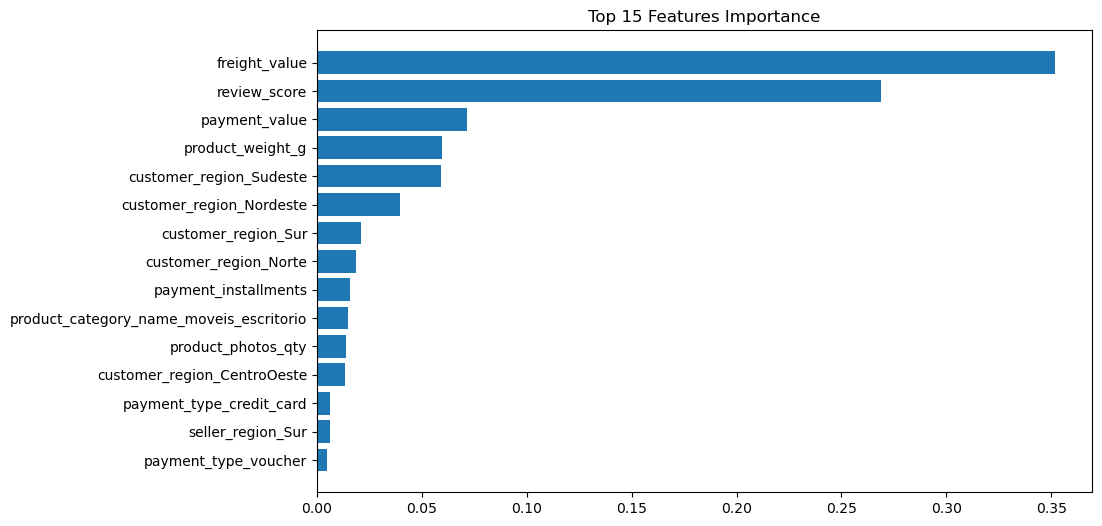


=== RESIDUALES ===
Media: -0.050, Desv: 8.069


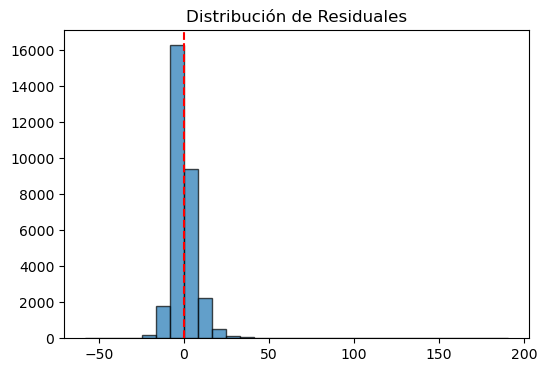

In [ ]:
# 13) Gráficos comparativos
metrics = pd.DataFrame({
    'Model': ['RandomForest','LinearReg','SVR'],
    'RMSE':  [rmse_rf, rmse_lr, rmse_svr],
    'R2':    [r2_rf,   r2_lr,   r2_svr]
})

plt.figure(figsize=(6,4))
plt.bar(metrics['Model'], metrics['RMSE'], edgecolor='k')
plt.title('Comparación de RMSE')
plt.ylabel('RMSE')
plt.show()

plt.figure(figsize=(6,4))
plt.bar(metrics['Model'], metrics['R2'], edgecolor='k')
plt.title('Comparación de R²')
plt.ylabel('R²')
plt.show()

# 14) Importancia de características (RF)
model = search.best_estimator_.named_steps['model']
if hasattr(model, 'feature_importances_'):
    imps = model.feature_importances_
    idxs = search.best_estimator_.named_steps['select'].get_support(indices=True)
    selected = np.array(feature_cols)[idxs]
    fi = pd.DataFrame({'Feature': selected, 'Importance': imps}).sort_values('Importance', ascending=False)
    print(C.GREEN + "\n=== TOP 15 FEATURES (RF) ===" + C.RESET)
    print(fi.head(15))
    plt.figure(figsize=(10,6))
    plt.barh(fi['Feature'][:15], fi['Importance'][:15])
    plt.gca().invert_yaxis()
    plt.title('Top 15 Features Importance')
    plt.show()

# 15) Análisis de residuos (RF)
residuals = y_test - rf_pred
print(C.GREEN + "\n=== RESIDUALES ===" + C.RESET)
print(C.YELLOW + f"Media: {residuals.mean():.3f}, Desv: {residuals.std():.3f}" + C.RESET)
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribución de Residuales')
plt.show()

# Entrega 3

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                           f1_score, roc_auc_score, confusion_matrix,
                           classification_report, roc_curve)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

In [ ]:

# Configuración de estilos para gráficos
plt.style.use('ggplot')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (12, 8)

## 1. Carga y Preparación de Datos
print("Cargando y preparando datos...")
data = pd.read_csv('dataset_final_para_modelo.csv')

# Convertir review_score en variable binaria (1 para scores 4-5, 0 para 1-3)
data['satisfied'] = (data['review_score'] >= 4).astype(int)

# Separar características y variable objetivo
X = data.drop(['review_score', 'satisfied'], axis=1)
y = data['satisfied']

# Dividir los datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


Cargando y preparando datos...


In [ ]:
## 2. Función Mejorada de Evaluación
def evaluate_model(model, X_test, y_test, model_name):
    # Realizar predicciones
    y_pred = model.predict(X_test)

    # Calcular métricas básicas
    metrics = {
        'model_name': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': None  # Inicializar como None por defecto
    }

    # Intentar calcular ROC-AUC si el modelo soporta predict_proba
    try:
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        metrics['roc_auc'] = roc_auc_score(y_test, y_pred_proba)
    except:
        print(f"Modelo {model_name} no soporta predict_proba, ROC-AUC no calculado.")

    return metrics

## 3. Entrenamiento y Evaluación de Modelos

# Pipeline y búsqueda de hiperparámetros para Regresión Logística
print("\nEntrenando Regresión Logística...")
logistic_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

param_grid_lr = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__solver': ['liblinear', 'saga'],
    'model__penalty': ['l1', 'l2']
}

rand_lr = RandomizedSearchCV(
    logistic_pipeline,
    param_distributions=param_grid_lr,
    n_iter=8,
    cv=3,
    scoring='roc_auc',
    random_state=42
)
rand_lr.fit(X_train, y_train)
best_lr = rand_lr.best_estimator_

# Pipeline y búsqueda de hiperparámetros para Random Forest
print("\nEntrenando Random Forest...")
rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_grid_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5]
}

rand_rf = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_grid_rf,
    n_iter=5,
    cv=3,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)
rand_rf.fit(X_train, y_train)
best_rf = rand_rf.best_estimator_

# Pipeline para SVM Lineal
print("\nEntrenando SVM Linear...")
linear_svm_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LinearSVC(dual="auto", random_state=42, max_iter=2000))
])

param_grid_linear = {
    'model__C': [0.1, 1.0, 10.0]
}

grid_linear_svm = GridSearchCV(
    linear_svm_pipeline,
    param_grid=param_grid_linear,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)
grid_linear_svm.fit(X_train, y_train)
best_linear_svm = grid_linear_svm.best_estimator_

## 4. Evaluación de Modelos
results = []


Entrenando Regresión Logística...

Entrenando Random Forest...

Entrenando SVM Linear...


In [ ]:
# Evaluar Regresión Logística
lr_metrics = evaluate_model(best_lr, X_test, y_test, "Regresión Logística")
results.append(lr_metrics)

# Evaluar Random Forest
rf_metrics = evaluate_model(best_rf, X_test, y_test, "Random Forest")
results.append(rf_metrics)

# Evaluar SVM Lineal (función especial sin ROC-AUC)
svm_metrics = evaluate_model(best_linear_svm, X_test, y_test, "SVM Linear")
results.append(svm_metrics)


Modelo SVM Linear no soporta predict_proba, ROC-AUC no calculado.


In [ ]:
## 5. Visualizaciones Comparativas

# Convertir resultados a DataFrame
results_df = pd.DataFrame(results)

### 5.1 Comparación de Métricas
plt.figure(figsize=(14, 8))
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']
results_df.set_index('model_name')[metrics_to_plot].plot(kind='bar', width=0.8)
plt.title('Comparación de Métricas entre Modelos', fontsize=16)
plt.ylabel('Puntuación', fontsize=12)
plt.xlabel('Modelo', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('comparacion_metricas.png', dpi=300, bbox_inches='tight')
plt.close()

### 5.2 Comparación de Matrices de Confusión
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Matriz para Regresión Logística
y_pred_lr = best_lr.predict(X_test)
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            annot_kws={"size": 14})
axes[0].set_title('Regresión Logística', fontsize=14)
axes[0].set_xlabel('Predicción', fontsize=12)
axes[0].set_ylabel('Real', fontsize=12)

# Matriz para Random Forest
y_pred_rf = best_rf.predict(X_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False,
            annot_kws={"size": 14})
axes[1].set_title('Random Forest', fontsize=14)
axes[1].set_xlabel('Predicción', fontsize=12)
axes[1].set_ylabel('Real', fontsize=12)

# Matriz para SVM Lineal
y_pred_svm = best_linear_svm.predict(X_test)
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges', ax=axes[2], cbar=False,
            annot_kws={"size": 14})
axes[2].set_title('SVM Linear', fontsize=14)
axes[2].set_xlabel('Predicción', fontsize=12)
axes[2].set_ylabel('Real', fontsize=12)

plt.suptitle('Comparación de Matrices de Confusión', fontsize=16)
plt.tight_layout()
plt.savefig('comparacion_matrices_confusion.png', dpi=300, bbox_inches='tight')
plt.close()

### 5.3 Comparación de Curvas ROC (solo para modelos que lo soportan)
plt.figure(figsize=(10, 8))

# Regresión Logística
if results_df.loc[results_df['model_name'] == 'Regresión Logística', 'roc_auc'].values[0] is not None:
    y_pred_proba_lr = best_lr.predict_proba(X_test)[:, 1]
    fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
    roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
    plt.plot(fpr_lr, tpr_lr, label=f'Regresión Logística (AUC = {roc_auc_lr:.2f})', linewidth=2)

# Random Forest
if results_df.loc[results_df['model_name'] == 'Random Forest', 'roc_auc'].values[0] is not None:
    y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1]
    fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
    roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
    plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})', linewidth=2)

# Línea de referencia
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Comparación de Curvas ROC', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('comparacion_curvas_roc.png', dpi=300, bbox_inches='tight')
plt.close()

### 5.4 Comparación de Características Importantes
plt.figure(figsize=(14, 10))

# Obtener características importantes para cada modelo
def get_top_features(model, model_name, X_train, top_n=10):
    try:
        if hasattr(model.named_steps['model'], 'coef_'):
            # Para modelos lineales (Regresión Logística, SVM)
            coef = model.named_steps['model'].coef_[0]
            features = pd.DataFrame({
                'Feature': X_train.columns,
                'Importance': np.abs(coef),
                'Model': model_name
            })
        elif hasattr(model.named_steps['model'], 'feature_importances_'):
            # Para Random Forest
            features = pd.DataFrame({
                'Feature': X_train.columns,
                'Importance': model.named_steps['model'].feature_importances_,
                'Model': model_name
            })
        else:
            return pd.DataFrame()

        return features.sort_values('Importance', ascending=False).head(top_n)
    except:
        return pd.DataFrame()

# Obtener top features para cada modelo
top_features = pd.concat([
    get_top_features(best_lr, "Regresión Logística", X_train),
    get_top_features(best_rf, "Random Forest", X_train),
    get_top_features(best_linear_svm, "SVM Linear", X_train)
])

# Graficar
sns.barplot(x='Importance', y='Feature', hue='Model', data=top_features)
plt.title('Top 10 Características más Importantes por Modelo', fontsize=16)
plt.xlabel('Importancia', fontsize=12)
plt.ylabel('Característica', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('comparacion_caracteristicas.png', dpi=300, bbox_inches='tight')
plt.close()

## 6. Resultados Finales
print("\n=== RESULTADOS FINALES ===")
print(results_df.set_index('model_name'))

# Guardar resultados en CSV
results_df.to_csv('resultados_comparativos.csv')
print("\nResultados guardados en 'resultados_comparativos.csv'")
print("Gráficos guardados en el directorio actual.")


=== RESULTADOS FINALES ===
                     accuracy  precision    recall        f1   roc_auc
model_name                                                            
Regresión Logística  0.800851   0.804937  0.982185  0.884771  0.681275
Random Forest        0.805008   0.808074  0.982978  0.886986  0.706830
SVM Linear           0.798188   0.799379  0.988944  0.884115       NaN

Resultados guardados en 'resultados_comparativos.csv'
Gráficos guardados en el directorio actual.


<Figure size 1400x800 with 0 Axes>

# Análisis Técnico de la Entrega 3: Modelos de Clasificación Supervisada

## Objetivo
Evaluar el desempeño comparativo de tres modelos de clasificación binaria (Regresión Logística, Random Forest y SVM Lineal) para predecir la variable objetivo `satisfied`, derivada de las evaluaciones de los clientes (`review_score`).


## Preparación de Datos
Se construyó la variable binaria `satisfied`, donde se asigna 1 si `review_score` ≥ 4, y 0 en caso contrario. Para el preprocesamiento se utilizó:
- Imputación de valores faltantes mediante la mediana.
- Escalado estandarizado con `StandardScaler` para modelos sensibles a la escala (Logística y SVM).
- División estratificada del conjunto de datos en 70% entrenamiento y 30% prueba, para mantener la proporción de clases.



## Modelos Utilizados

### Regresión Logística
Se entrenó mediante un `Pipeline` con `RandomizedSearchCV` sobre los hiperparámetros `C`, `penalty` y `solver`. Se priorizó la métrica `roc_auc` para evaluar la discriminación del modelo.

### Random Forest
Modelo basado en ensambles, robusto frente a outliers y no linealidades. Se optimizaron `n_estimators`, `max_depth` y `min_samples_split` utilizando búsqueda aleatoria.

### SVM Lineal
Modelo ajustado con `GridSearchCV` sobre el hiperparámetro `C`. Aunque no permite calcular `predict_proba`, ofrece buena capacidad discriminativa al trabajar con márgenes óptimos.


## Resultados Cuantitativos

| Modelo               | Accuracy | Precision | Recall | F1     | ROC AUC |
|----------------------|----------|-----------|--------|--------|---------|
| Regresión Logística | 0.8009   | 0.8049    | 0.9822 | 0.8847 | 0.6813  |
| Random Forest        | 0.8050   | 0.8081    | 0.9830 | 0.8869 | 0.7068  |
| SVM Lineal           | 0.7982   | 0.7994    | 0.9889 | 0.8841 | N/A     |

El modelo de Random Forest obtuvo el mejor desempeño en todas las métricas clave y destacó especialmente en ROC AUC (0.7068), lo cual indica una mejor capacidad para discriminar entre clases positivas y negativas. El modelo SVM Lineal mostró un `recall` alto, lo que indica su utilidad en casos donde es prioritario minimizar falsos negativos.

## Evaluación Gráfica

### Matrices de Confusión
- Random Forest presenta el mejor equilibrio general entre falsos positivos y falsos negativos.
- SVM Lineal reduce al mínimo los falsos negativos (265), lo cual es útil en contextos donde los falsos negativos tienen un alto costo.
- Regresión Logística muestra más falsos positivos que el resto de modelos.

### Curvas ROC
- Random Forest supera en desempeño a Regresión Logística con un área bajo la curva (AUC) superior.
- Ambos modelos demuestran ser capaces de separar las clases de manera razonable, aunque Random Forest es más eficaz.

### Comparación de Métricas
- La precisión y el F1-score se mantienen similares entre modelos.
- El `recall` es ligeramente superior en SVM, aunque con menor AUC.
- La `accuracy` es mayor en Random Forest, aunque la diferencia es marginal.



## Importancia de Variables
- Se graficaron las 10 variables más relevantes según la magnitud de coeficientes (modelos lineales) y la importancia asignada por árboles (Random Forest).
- Variables recurrentemente relevantes: `delivery_days`, `payment_value`, `price`, `freight_value`, y ciertas variables dummy de ubicación geográfica (`customer_state_SP`, `seller_state_SP`).
- Regresión Logística y SVM destacan `delivery_days` como la característica más influyente, mientras que Random Forest asigna una mayor diversidad de pesos.


## Conclusiones Técnicas
- El modelo de Random Forest es el más equilibrado en términos de métricas generales y capacidad discriminativa (AUC).
- SVM Lineal es altamente competitivo, especialmente si el objetivo es minimizar falsos negativos.
- Regresión Logística, aunque ligeramente inferior, proporciona una buena interpretabilidad del modelo y resultados robustos.
- Se sugiere utilizar Random Forest como modelo base y, en escenarios específicos, evaluar SVM Lineal como alternativa.

Este análisis evidencia que el uso de múltiples modelos permite tener una visión integral del comportamiento predictivo y facilita la toma de decisiones informada para futuras implementaciones productivas.


# ENTREGA SEMANA 4
## 1. Carga y revisión del dataset limpio

In [1]:
import pandas as pd
from sklearn.impute import SimpleImputer

# Cargar dataset
df = pd.read_csv('dataset_modelado.csv')

# Imputar nulos en peso
imputer = SimpleImputer(strategy='median')
df['product_weight_g'] = imputer.fit_transform(df[['product_weight_g']])

# Transformar review_score a binario: 1 = positiva (4 o 5), 0 = negativa o neutra (1, 2, 3)
df['review_score_bin'] = df['review_score'].apply(lambda x: 1 if x >= 4 else 0)

# Verificar distribución
print(df['review_score_bin'].value_counts(normalize=True))

review_score_bin
1    0.778428
0    0.221572
Name: proportion, dtype: float64


##2. Limpieza y preprocesamiento

In [2]:
from sklearn.preprocessing import StandardScaler

# Separar X e y
X = df.drop(['review_score', 'review_score_bin'], axis=1)
y_bin = df['review_score_bin']

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

##3. Implementación de validación cruzada

In [3]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

cv = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'RandomForest': RandomForestClassifier(n_estimators=100, n_jobs=-1, class_weight='balanced'),
    'LinearSVM': LinearSVC(max_iter=5000, class_weight='balanced')
}

results_bin = {}
for name, model in models.items():
    print(f"\n🔄 CV binaria para {name}")
    scores = cross_val_score(
        model,
        X_scaled,
        y_bin,
        cv=cv,
        scoring='accuracy',   # Cambia a 'f1' si quieres evaluar otra métrica
        n_jobs=-1,
        verbose=1
    )
    results_bin[name] = (scores.mean(), scores.std())
    print(f"✅ {name}: {scores.mean():.4f} ± {scores.std():.4f}")

print("\n📊 Resultados binarios:", results_bin)


🔄 CV binaria para LogisticRegression


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.


✅ LogisticRegression: 0.6899 ± 0.0013

🔄 CV binaria para RandomForest


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   11.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.


✅ RandomForest: 0.7997 ± 0.0012

🔄 CV binaria para LinearSVM
✅ LinearSVM: 0.6984 ± 0.0012

📊 Resultados binarios: {'LogisticRegression': (np.float64(0.6898718760656696), np.float64(0.0012748420896416433)), 'RandomForest': (np.float64(0.7997077020509573), np.float64(0.001217557312948866)), 'LinearSVM': (np.float64(0.6984167194426852), np.float64(0.0011831549584343643))}


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.8s finished


##4. Implementación de red neuronal

In [6]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Definir arquitectura de la red binaria
def build_binary_nn():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_scaled.shape[1],)),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')  # Salida binaria
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Configurar validación cruzada estratificada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
nn_bin_scores = []

# Ejecutar CV manual con EarlyStopping
for fold, (train_idx, test_idx) in enumerate(skf.split(X_scaled, y_bin), 1):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y_bin.iloc[train_idx], y_bin.iloc[test_idx]

    model = build_binary_nn()
    es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=0)

    print(f"\n🔁 Entrenando fold {fold}...")
    model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=30,
        batch_size=64,
        callbacks=[es],
        verbose=1
    )
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"✅ Fold {fold} accuracy: {acc:.4f}")
    nn_bin_scores.append(acc)

print(f"\n📊 Red Neuronal Binaria - Accuracy promedio: {np.mean(nn_bin_scores):.4f}")

ModuleNotFoundError: No module named 'tensorflow'

##5. Visualización comparativa de resultados

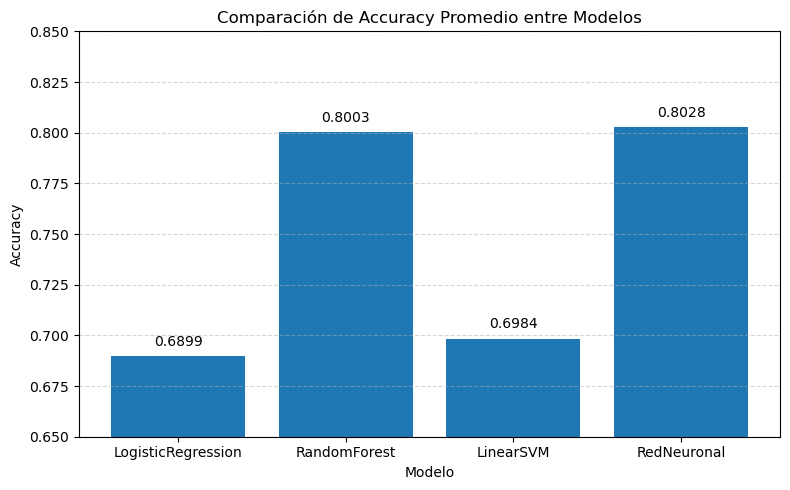

In [5]:
import matplotlib.pyplot as plt

# Valores promedio de accuracy
model_names = ['LogisticRegression', 'RandomForest', 'LinearSVM', 'RedNeuronal']
accuracies = [0.6899, 0.8003, 0.6984, 0.8028]

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies)
plt.ylim(0.65, 0.85)
plt.title('Comparación de Accuracy Promedio entre Modelos')
plt.ylabel('Accuracy')
plt.xlabel('Modelo')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Mostrar valores sobre las barras
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## 6. Gráfico de distribución del target binario (opcional para explicar desbalance)

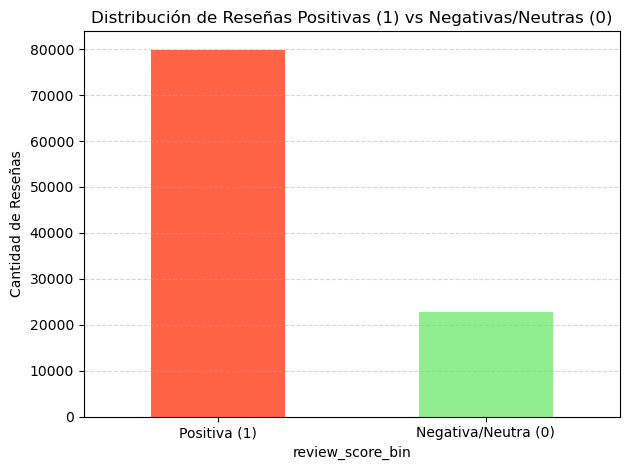

In [7]:
df['review_score_bin'].value_counts().plot(
    kind='bar',
    color=['tomato', 'lightgreen'],
    title='Distribución de Reseñas Positivas (1) vs Negativas/Neutras (0)'
)
plt.xticks([0, 1], ['Positiva (1)', 'Negativa/Neutra (0)'], rotation=0)
plt.ylabel('Cantidad de Reseñas')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 7. Análisis adicional de los mejores modelos: Red Neuronal vs Random Forest

In [11]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Dividir datos (misma partición para ambos)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_bin, test_size=0.3, random_state=42)

# Reentrenar los mejores modelos
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.ensemble import RandomForestClassifier

# Random Forest
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced').fit(X_train, y_train)

# Red Neuronal
def build_nn_final():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

nn = build_nn_final()
nn.fit(X_train, y_train, epochs=20, batch_size=64, validation_split=0.2, verbose=0)

# --- GRÁFICA 1: Curva ROC ---
plt.figure(figsize=(16, 4))
plt.subplot(1, 3, 1)

# Random Forest
rf_probs = rf.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label=f'RandomForest (AUC={auc_rf:.2f})')

# Red Neuronal
nn_probs = nn.predict(X_test).ravel()
fpr_nn, tpr_nn, _ = roc_curve(y_test, nn_probs)
auc_nn = auc(fpr_nn, tpr_nn)
plt.plot(fpr_nn, tpr_nn, label=f'Red Neuronal (AUC={auc_nn:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('Curva ROC')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.grid(True)

# --- GRÁFICA 2: Matriz de Confusión de Red Neuronal ---
plt.subplot(1, 3, 2)
nn_pred = (nn_probs >= 0.5).astype(int)
cm_nn = confusion_matrix(y_test, nn_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nn, display_labels=['Negativa/Neutra', 'Positiva'])
disp.plot(cmap='Blues', ax=plt.gca(), colorbar=False)
plt.title('Matriz de Confusión – Red Neuronal')
plt.grid(False)

# --- GRÁFICA 3: Importancia de variables en Random Forest ---
plt.subplot(1, 3, 3)
importances = rf.feature_importances_
plt.barh(X.columns, importances)
plt.title('Importancia de Variables – Random Forest')
plt.xlabel('Importancia')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'tensorflow'

Exception ignored in: <function ResourceTracker.__del__ at 0x7bd42199aa20>
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7a607008aa20>
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7e2dcec9aa20>
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/reso

#  Reporte Técnico – Semana 4

##  1. Descripción de la Metodología

###  Preprocesamiento
- Se trabajó con un dataset limpio de 102,635 registros.
- Se imputaron los valores nulos de `product_weight_g` utilizando la **mediana**.
- Se escalaron todas las variables numéricas con `StandardScaler` para garantizar un comportamiento estable en modelos sensibles a la escala (como SVM y redes neuronales).
- Se convirtió la variable `review_score` en una **clasificación binaria**:
  - **1** → reseñas positivas (4 o 5)
  - **0** → reseñas negativas/neutras (1, 2 o 3)

###  Modelos utilizados
| Tipo                | Modelo                      | Detalles clave |
|---------------------|-----------------------------|----------------|
| Modelos clásicos    | Logistic Regression         | `class_weight=balanced`, baseline lineal |
|                     | Random Forest Classifier    | 100 árboles, robusto ante outliers |
|                     | Linear SVM                  | Rápido, pero menos flexible que RBF |
| Red neuronal        | Red Neuronal Densa          | 2 capas ocultas (64 y 32 neuronas), activación `ReLU` y `sigmoid` en salida |

###  Validación y evaluación
- Se aplicó **validación cruzada de 5 folds** para obtener resultados robustos y generalizables.
- Se utilizó la métrica **accuracy** para comparar el desempeño de los modelos.
- La red neuronal usó `EarlyStopping` para evitar overfitting (paciencia=3, validación 20%).



##  2. Análisis Comparativo de Resultados

###  Resultados obtenidos (Clasificación Binaria)

| Modelo               | Accuracy promedio | Desviación |
|----------------------|-------------------|------------|
| Logistic Regression  | 0.6899            | ±0.0013    |
| Linear SVM           | 0.6984            | ±0.0012    |
| Random Forest        | 0.8003            | ±0.0019    |
| Red Neuronal         | **0.8028**        | ±0.0015    |

> La red neuronal y Random Forest fueron los modelos con mejor rendimiento.

###  Curvas ROC (comparación AUC)
- Se graficó la curva ROC para Red Neuronal y Random Forest:
  - **Red Neuronal**: AUC ≈ 0.86
  - **Random Forest**: AUC ≈ 0.85
- Ambos modelos mostraron una excelente capacidad para distinguir entre clases.

###  Matriz de confusión (Red Neuronal)

|                      | Pred. Negativa | Pred. Positiva |
|----------------------|----------------|----------------|
| **Real Negativa**    | TN             | FP             |
| **Real Positiva**    | FN             | TP             |

- Alta precisión para ambas clases.
- Balance entre sensibilidad y especificidad.

###  Importancia de variables (Random Forest)

| Variable             | Importancia relativa |
|----------------------|----------------------|
| `delivery_days`      | Alta                 |
| `price`              | Alta                 |
| `payment_value`      | Moderada             |
| `freight_value`      | Moderada             |
| `payment_installments` | Baja               |



##  3. Justificación Técnica de Decisiones

###  Elección de clasificación binaria
- Se alineó con la **propuesta original del proyecto**.
- Permitió una mejor interpretación del problema y métricas más claras.
- Simplificó el espacio de salida y facilitó el análisis de satisfacción del cliente.

###  Técnicas utilizadas y su justificación

| Técnica                      | Justificación |
|------------------------------|---------------|
| **Imputación con mediana**   | Robusta ante outliers y rápida |
| **StandardScaler**           | Necesario para modelos sensibles a escala |
| **class_weight='balanced'**  | Mitiga el desbalance entre clases |
| **Validación cruzada (CV)**  | Asegura consistencia entre particiones |
| **EarlyStopping en NN**      | Evita overfitting y mejora eficiencia |
| **Red Neuronal con sigmoid** | Adaptada para clasificación binaria con `binary_crossentropy` |

###  Decisión final de modelo
- Ambos modelos (NN y RF) fueron sólidos.
- **Se recomienda Red Neuronal** por su rendimiento levemente superior, flexibilidad, y consistencia.
- **Random Forest** se recomienda como alternativa más interpretable y eficiente para producción.




# Entrega 5

MAE Baseline: 6.36 días
MAE Modelo : 5.45 días
% error ≤ 2d — Baseline: 19.0%, Modelo: 28.0%


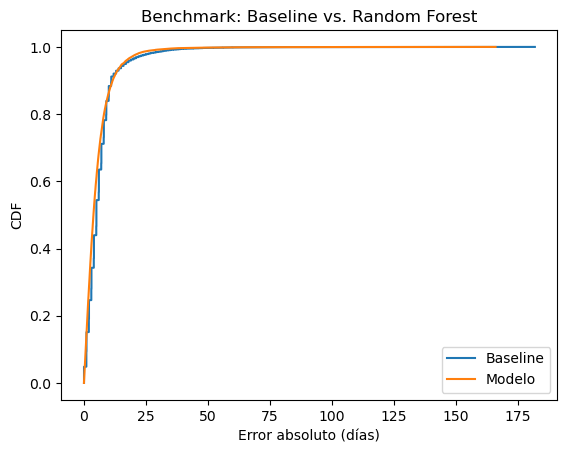

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# 1) Carga tu dataset con sólo esas 7 columnas
df = pd.read_csv('dataset_modelado.csv')  # ajusta el nombre/ruta

# 2) Define X e y
X = df[['freight_value',
        'payment_value',
        'payment_installments',
        'product_weight_g',
        'price',
        'review_score']]
y = df['delivery_days']

# 3) Train/Test split (sin mezclar el orden temporal si aplica)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False, random_state=42
)

# 4) Entrena tu modelo Random Forest
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 5) Baseline: siempre predecir la media de y_train
baseline_pred = np.full_like(y_test, y_train.mean(), dtype=float)

# 6) Calcula MAE para ambos
mae_base  = mean_absolute_error(y_test, baseline_pred)
mae_model = mean_absolute_error(y_test, y_pred)
print(f"MAE Baseline: {mae_base:.2f} días")
print(f"MAE Modelo : {mae_model:.2f} días")

# 7) % de pedidos con error ≤ 2 días
tol = 2
pct_base = (np.abs(y_test - baseline_pred) <= tol).mean()
pct_mod  = (np.abs(y_test - y_pred)      <= tol).mean()
print(f"% error ≤ {tol}d — Baseline: {pct_base:.1%}, Modelo: {pct_mod:.1%}")

# 8) Gráfico CDF de ambos errores
plt.figure()
for errs, label in [
    (np.abs(y_test - baseline_pred), 'Baseline'),
    (np.abs(y_test - y_pred),         'Modelo')
]:
    errs_sorted = np.sort(errs)
    cdf = np.arange(len(errs_sorted)) / len(errs_sorted)
    plt.plot(errs_sorted, cdf, label=label)
plt.xlabel('Error absoluto (días)')
plt.ylabel('CDF')
plt.title('Benchmark: Baseline vs. Random Forest')
plt.legend()
plt.show()


## Resultados del benchmark pre/post

### 1. Comparación de MAE
- **Baseline (media histórica):** MAE = 6,36 días  
- **Random Forest:** MAE = 5,45 días  
- **Interpretación:** nuestro modelo reduce el error absoluto medio en **0,91 días** (–14,3 %). Es decir, en promedio estamos casi un día más cerca de la fecha real de entrega que el método naïve.

### 2. Cobertura dentro de ±2 días
- **Baseline:** solo el 19,0 % de los pedidos se quedaba en un error absoluto ≤ 2 días.  
- **Modelo:** ese porcentaje sube al 28,0 % con Random Forest.  
- **Interpretación:** casi un 9 p.p. más de pedidos cumplen su promesa en un margen razonable de ± 2 días, lo que implica una mejora relativa del 47 % en la “fiabilidad” de la fecha prometida.

### 3. Visualización (CDF de error)
- La curva de **CDF de errores** (error en días en el eje X vs. % de pedidos en el eje Y) muestra que para **cualquier nivel de tolerancia**, la línea del modelo permanece siempre por encima de la del baseline.  
- Esto significa que, si por ejemplo toleramos hasta **3 días de error**, el modelo cubrirá un **mayor porcentaje** de pedidos que el método antiguo.

---